# Optical Spectrum Analysis Module

### Welcome back, cosmic detectives!

So far in our FRB host galaxy adventure, we’ve been working like galactic sleuths: we tracked down possible host galaxies in archival imaging data, sharpened our view by reducing optical images, and prepped and cleaned up the spectra so they’re ready for science. But now comes the exciting part - turning those rainbow streaks of light into astrophysical clues! In this module, we’ll roll up our sleeves and dive into spectral analysis: extracting redshifts, measuring emission and absorption lines, and decoding what they tell us about the host galaxy’s properties -- its distance, star formation activity, and more! Think of it like going from spotting the suspect to actually interrogating them: the spectrum holds the answers to who this galaxy really is and why it’s connected to our mysterious FRB. Get ready to transform data into discovery - because now, the photons start talking!

### Objective
Extract spectroscopic redshift and nebular emission line fluxes of an FRB host galaxy from its optical spectrum to identify the dominant ionization mechanism in the host galaxy and measure its star-formation rate.

### Required dependencies
All the software required for today's tutorials should be readily accessible in the docker containers, of which you all expert users by now! At a later epoch, should you choose to do so, nominally, you should be able to install the python modules on your computer with `pip install <module>`. Here, we link to the official webpages of all the software for future reference.

* [astropy](https://www.astropy.org/)
* [numpy](https://numpy.org/)
* [matplotlib](https://matplotlib.org/)
* [seaborn](https://seaborn.pydata.org/)
* [pandas](https://pandas.pydata.org/)
* [pPXF](https://pypi.org/project/ppxf/)

The following cell imports all of these packages for this module. Kindly ensure all these imports go through successfully. If you encounter any issues with the software, please reach out to the nearest Docker expert for assistance.


In [1]:
# Importing all the relevant software packages
from os import path
import numpy as np
from astropy.io import ascii
import astropy.cosmology.units as cu
import astropy.units as u
from astropy.cosmology import WMAP9 as cosmo
import pandas as pd
from sklearn.linear_model import LinearRegression
import pandas as pd

from ppxf.ppxf import ppxf
import ppxf.ppxf_util as util
import ppxf.miles_util as lib

import warnings
warnings.filterwarnings("ignore")

# Setting up the plotting environment
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context('talk') 
sns.set(font_scale=1.5)
sns.set_palette('colorblind')
sns.set_style('ticks')
plt.rcParams["font.family"] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Tahoma', 'Verdana', 'Lucida Grande', 'DejaVu Sans']


Wellll.... Before diving deep into the state-of-the-art spectral analyses software used by the FRB community, how about we build some intution first?! 

Lets look at the rest-frame spectrum of [NGC3512](https://www.wikidata.org/wiki/Q1105138), a beautiful spiral galaxy in our neighborhood. The spectrum is from public [Sloan Digital Sky Survey (SDSS)](https://www.sdss4.org/) data with a spectral resolution of $\Delta \lambda/\lambda \sim 2000$.  

(3500.0, 6700.0)

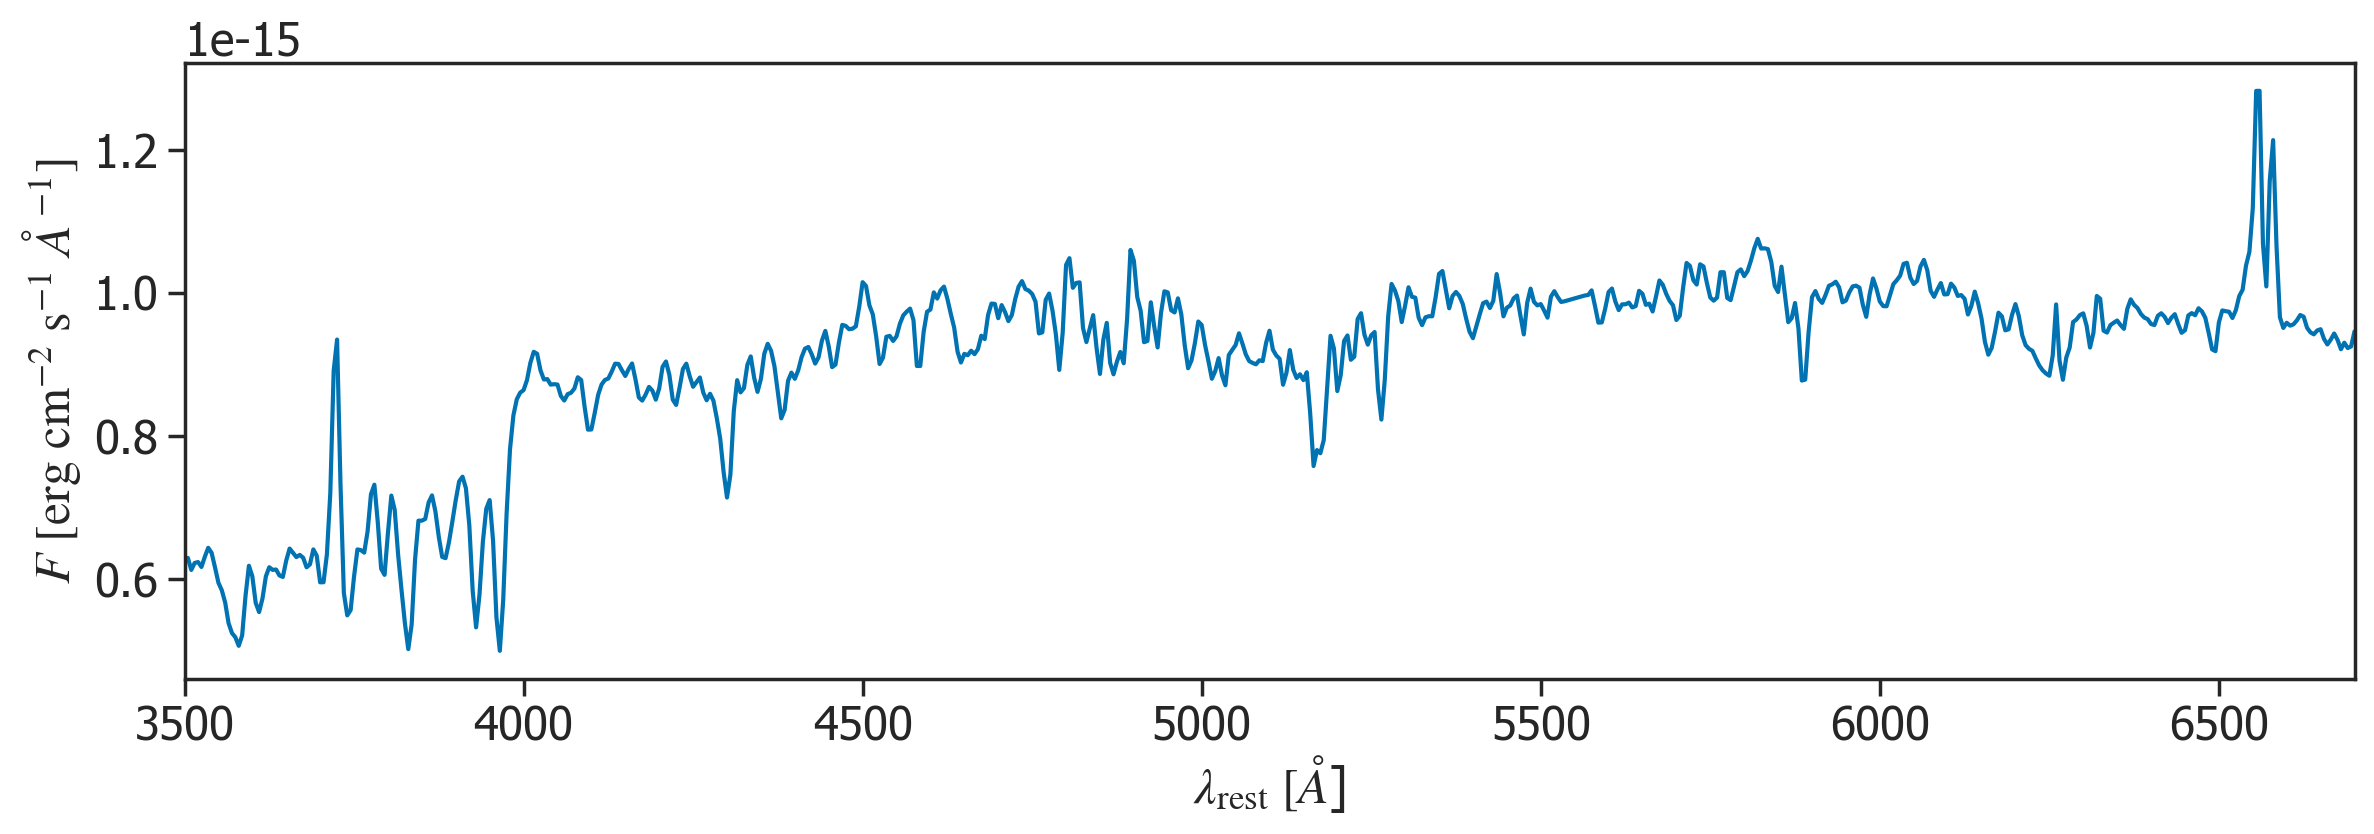

In [2]:
NGC3512 = ascii.read('data/NGC3512_spec.dat')

fig = plt.figure(figsize=(14, 4)); ax = plt.subplot()
ax.plot(NGC3512["lam"], NGC3512["flam"]*1e-17)
ax.set_xlabel(r'$\lambda_\mathrm{{rest}}~[\AA$]', labelpad=1)
ax.set_ylabel(r"$F~[\mathrm{erg}~\mathrm{cm}^{-2}~\mathrm{s}^{-1}~\AA^{-1}]$")
ax.set_xlim(3500, 6700)


Doesn't look very impressive, does it?! But trust me, as someone who looks at FRB host galaxy spectra all the time, this one is a miracle. Spoiler: Detecting stellar absorption features, and indeed, even emission line features of galaxies can be very challenging for sources at high redshifts. 

Back to the main track: A galaxy spectrum is basically a beautiful, noisy cocktail — the blended light of billions of stars plus gas that’s doing all kinds of theatrical tricks. You can readily spot most of these features in the spectrum above.

* The **stellar continuum** shaped by the mixture of star types: hot O and B-type stars give a blue, feature-poor continuum (and show He II/He I features), A-type stars scream with strong Balmer absorption lines (Hβ, Hγ …), G-type stars show weaker Balmer lines and increasingly prominent metal lines, while cooler K-type stars contribute a red continuum decorated with strong metal lines (Ca II H&K at 3934.78/3969.59 Å and Mg at 5176.70 Å). The overall continuum slope and the 4000-Å break (D4000) tells you about the age and metallicity mix of the stellar population.

* **On top of that sits the gas**, which behaves like pranksters: H II regions excited by young massive stars flood the spectrum with recombination emission lines (Hα 6564.61 Å, Hβ 4862.68 Å) and strong forbidden lines ([O II] doublet 3727.092/3729.875, [O III] doublet 4960.295/5008.240, [N II] doublet 6549.86/6585.27, [S II] doublet 6718.29/6732.67) whose ratios encode metallicity and ionization; AGNs crank the ionization up, producing high-ionization forbidden lines, often very broad permitted lines from a fast broad-line region, and different narrow-line signatures from the narrow-line region; shocks and outflows add yet another level of complexity.

* There are also **interstellar absorption features** (Na I 5895.6, narrow components of Ca II), **dust reddening** that reshapes the continuum, and kinematic effects — **rotation and velocity dispersion** — that shift and broaden every line.

----

**Bonus Question: What causes the 4000-Å break?**

**Solution to the Bonus Question:** The famous 4000-Å break (often called the Balmer break or 4000-Å discontinuity) is caused by a combination of effects, both tied to how atoms in stars absorb light:

* **Hydrogen Balmer absorption** (dominant in hot stars): Hydrogen atoms in their second energy level (n=2) can absorb photons that are energetic enough to kick the electron to higher levels. Photons with wavelengths shorter than ~3646 Å (the Balmer limit) get gobbled up, producing a sharp drop in flux just blueward of that wavelength. This is especially strong in A-type stars, which have lots of hydrogen in the right state.

* **Metal line blanketing** (dominant in cooler stars): In cooler stars (F, G, K types), hydrogen isn’t excited enough to produce strong Balmer absorption. Instead, the forest of metal lines (mainly from ionized metals like Fe II, Ca II, Mg II, CN, etc.) in the 3700–4000 Å region absorbs a ton of blue/UV light. This line blanketing makes the flux drop even more below ~4000 Å.

So the “4000-Å break” isn’t just one feature — it’s the combined effect of the Balmer edge at 3646 Å, strongest in A stars, and heavy metal line blanketing around 4000 Å, strongest in older, metal-rich populations. In galaxy spectra, a strong break usually means the light is dominated by older, cooler stars (like in elliptical galaxies or bulges). A weak break means more contribution from young, hot stars (like in star-forming galaxies). Astronomers often use the D4000 index (the flux ratio just redward vs. just blueward of 4000 Å) as a quick diagnostic of stellar population age and metallicity.

----

So yes: galaxy spectrum is a huge, glorious mess! The practical way in is to decompose: first model the stellar continuum (using stellar templates or population synthesis) to explain the absorption features and continuum shape, subtract that off, and then measure the gas emission/absorption on the residuals — that stepwise approach turns the chaos into interpretable physical pieces.

Assume that the spectrum above is composed of stars of 7 spectral types. Lets construct a linear least-squares program that solves for the linear combination of stellar spectra that best reproduces the observed galaxy spectrum.

In [3]:
# Key spectral features by stellar type
spectral_features = {
    'O7-V': [(4102.89, "Hδ"), (4341.68, "Hγ"), (4862.68, "Hβ"), (4686, "He II 4686"), (4471, "He I 4471"), (4541, "He II 4541")],
    'B3-V': [(4102.89, "Hδ"), (4341.68, "Hγ"), (4862.68, "Hβ"), (4471, "He I 4471")],
    'A1-V': [(4102.89, "Hδ"), (4341.68, "Hγ"), (4862.68, "Hβ"), (6564.61, "Hα")],
    'G1-V': [(3934.777, "Ca II K"), (3969.588, "Ca II H"), (4305.61, "G band (CH)"), (5176.7, "Mg b")],
    'G5-III': [(3934.777, "Ca II K"), (3969.588, "Ca II H"), (4305.61, "G band (CH)"), (5176.7, "Mg b")],
    'K4-III': [(3934.777, "Ca II K"), (3969.588, "Ca II H"), (5176.7, "Mg b"), (5895.6, "Na I D"), (6170, "TiO")],
    'K4-V': [(3934.777, "Ca II K"), (3969.588, "Ca II H"), (5176.7, "Mg b"), (5895.6, "Na I D"), (6170, "TiO")],
}
stellar_types = list(spectral_features.keys())

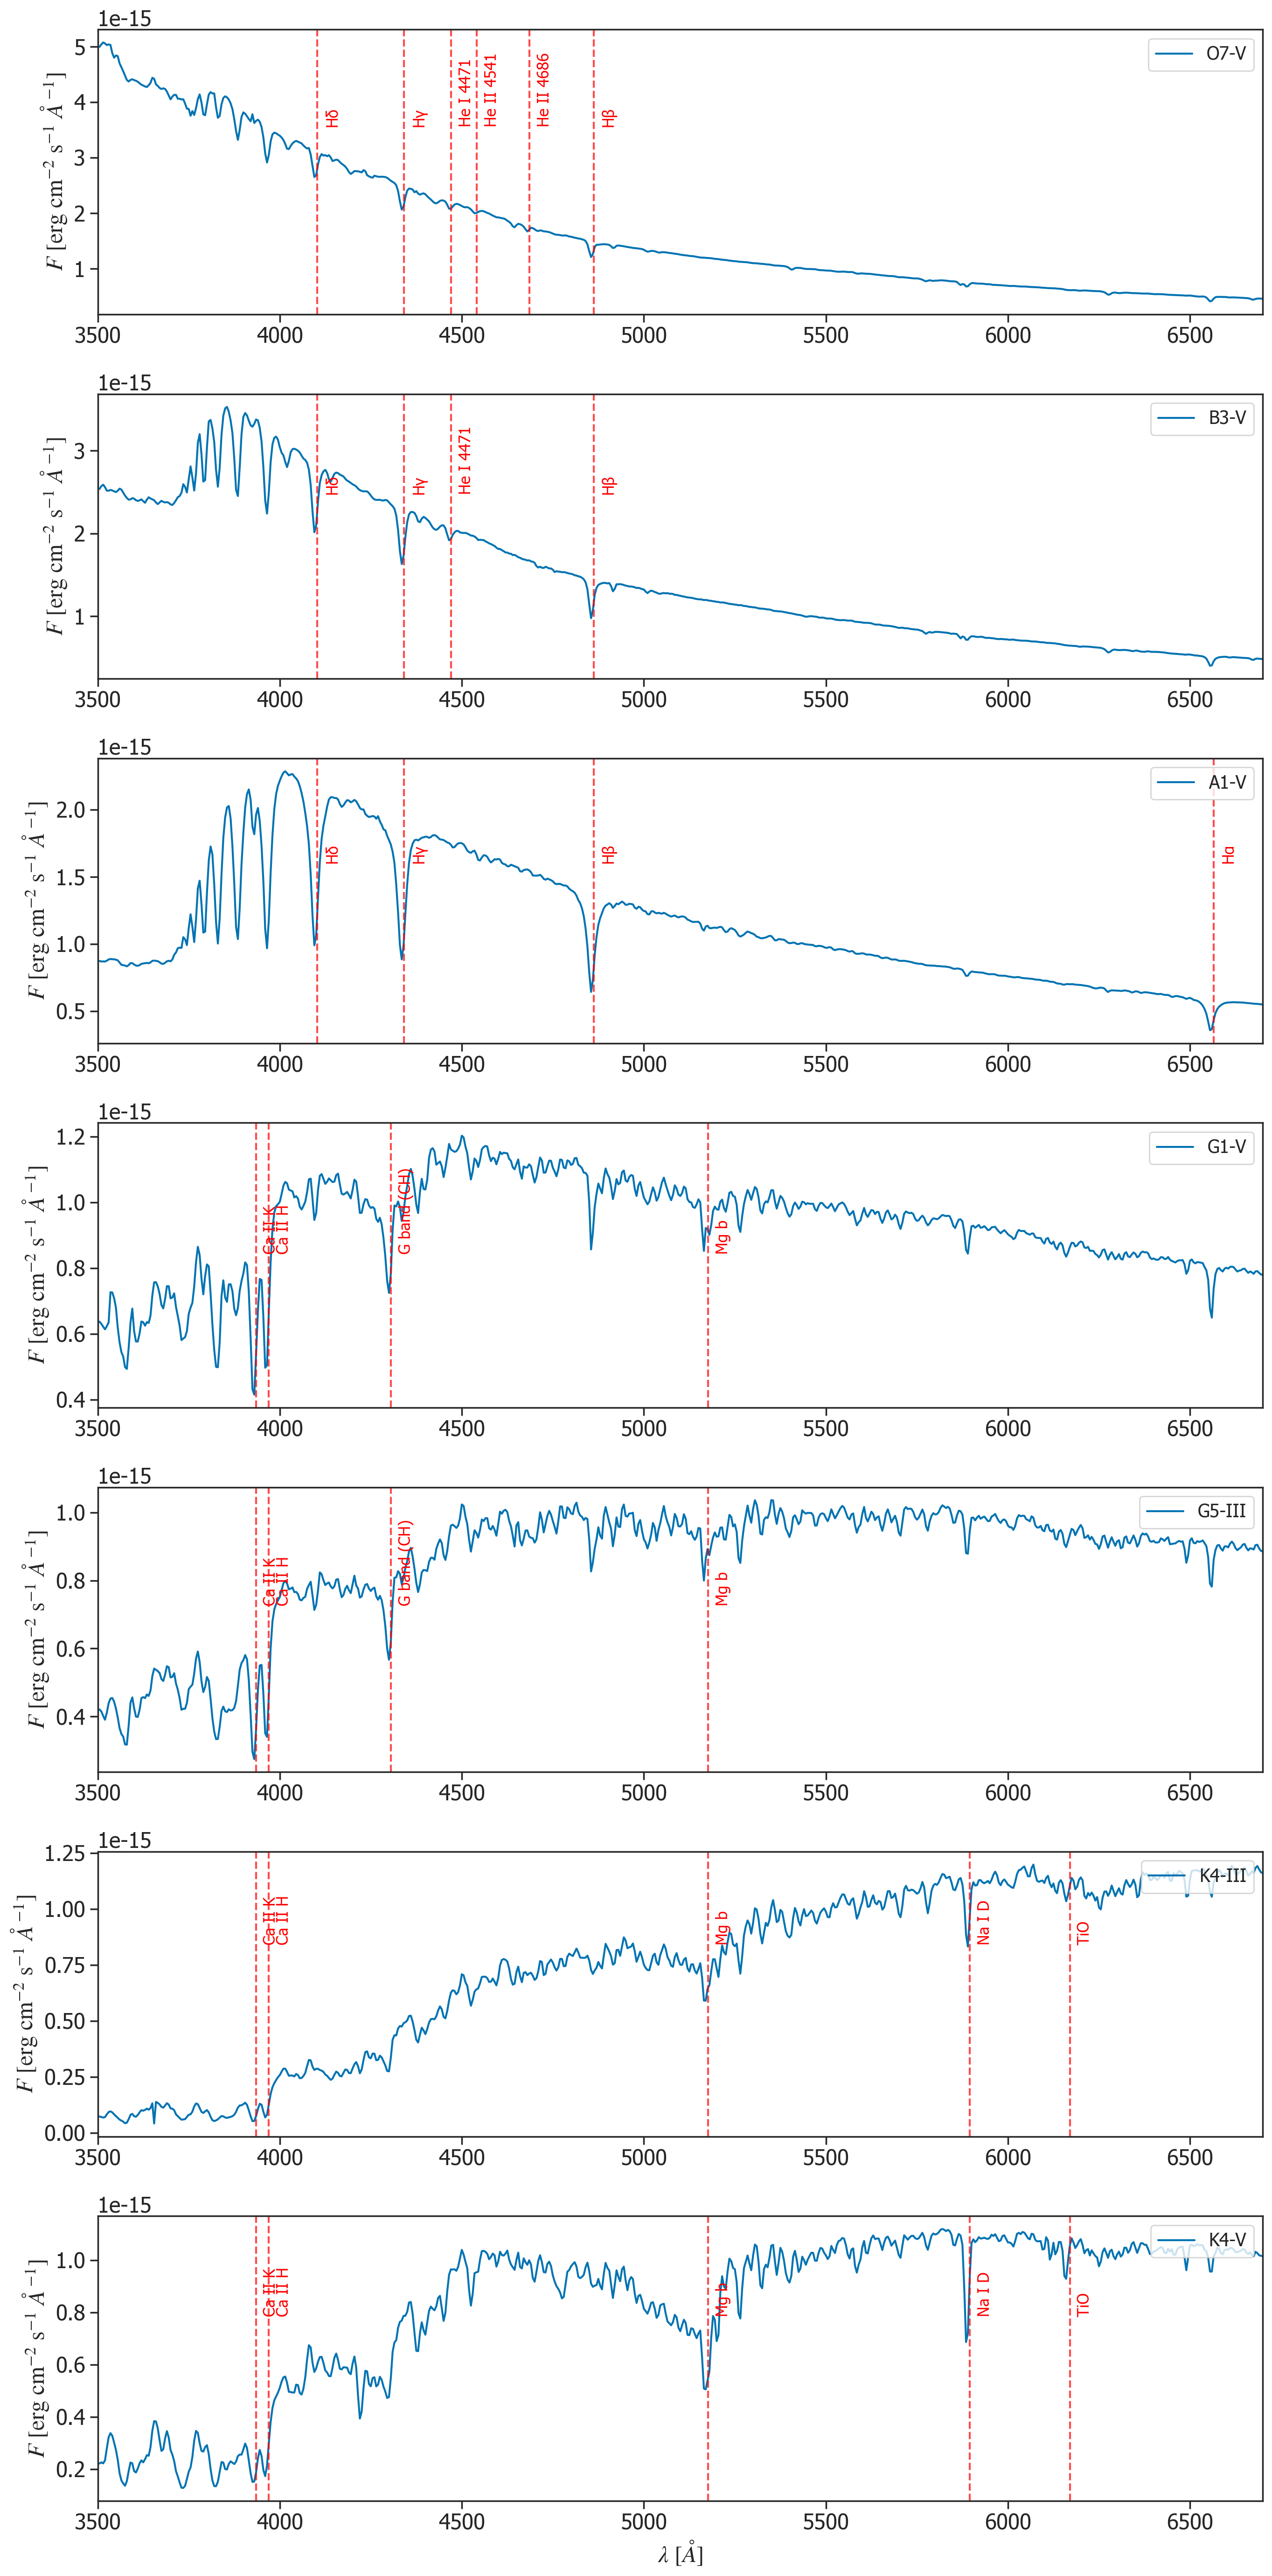

In [4]:
fig, axes = plt.subplots(len(stellar_types), 1, figsize=(14, 4*7))

stellar_spectra = []
for i in range(len(stellar_types)):
    stellar_type = stellar_types[i]
    data = pd.read_csv(f"data/{stellar_type}.dat", sep=' '); data = data[data["lambda"] <= 6700]
    stellar_spectra.append(data["Flambda"])
    axes[i].plot(data["lambda"], data["Flambda"]*1e-17, label=stellar_type)
    axes[i].set_xlim(3500, 6700)
    axes[i].legend(fontsize=14, loc="upper right")
    axes[i].set_ylabel(r"$F~[\mathrm{erg}~\mathrm{cm}^{-2}~\mathrm{s}^{-1}~\AA^{-1}]$")

    # Mark spectral features
    if stellar_type in spectral_features:
        for wl, label in spectral_features[stellar_type]:
            axes[i].axvline(wl, color='red', ls='--', alpha=0.7)
            axes[i].text(wl+20, 0.7*max(data["Flambda"]*1e-17), label, rotation=90, va='bottom', ha='left', fontsize=12, color='red')

axes[-1].set_xlabel(r'$\lambda~[\AA]$')
plt.tight_layout()
plt.show()


Hmmmm given these stellar spectra, just intutively, what do you think the composition of this particular galaxy is going to look like? Do we expect to see a lot of young (O/B-type) stars or old (G/K-type) stars? 

Lets quantitatively find out!

[0.00594527 0.05038167 0.06831373 0.         0.40632796 0.31170839
 0.15732299]


Text(0, 0.5, '$F$ (normalized)')

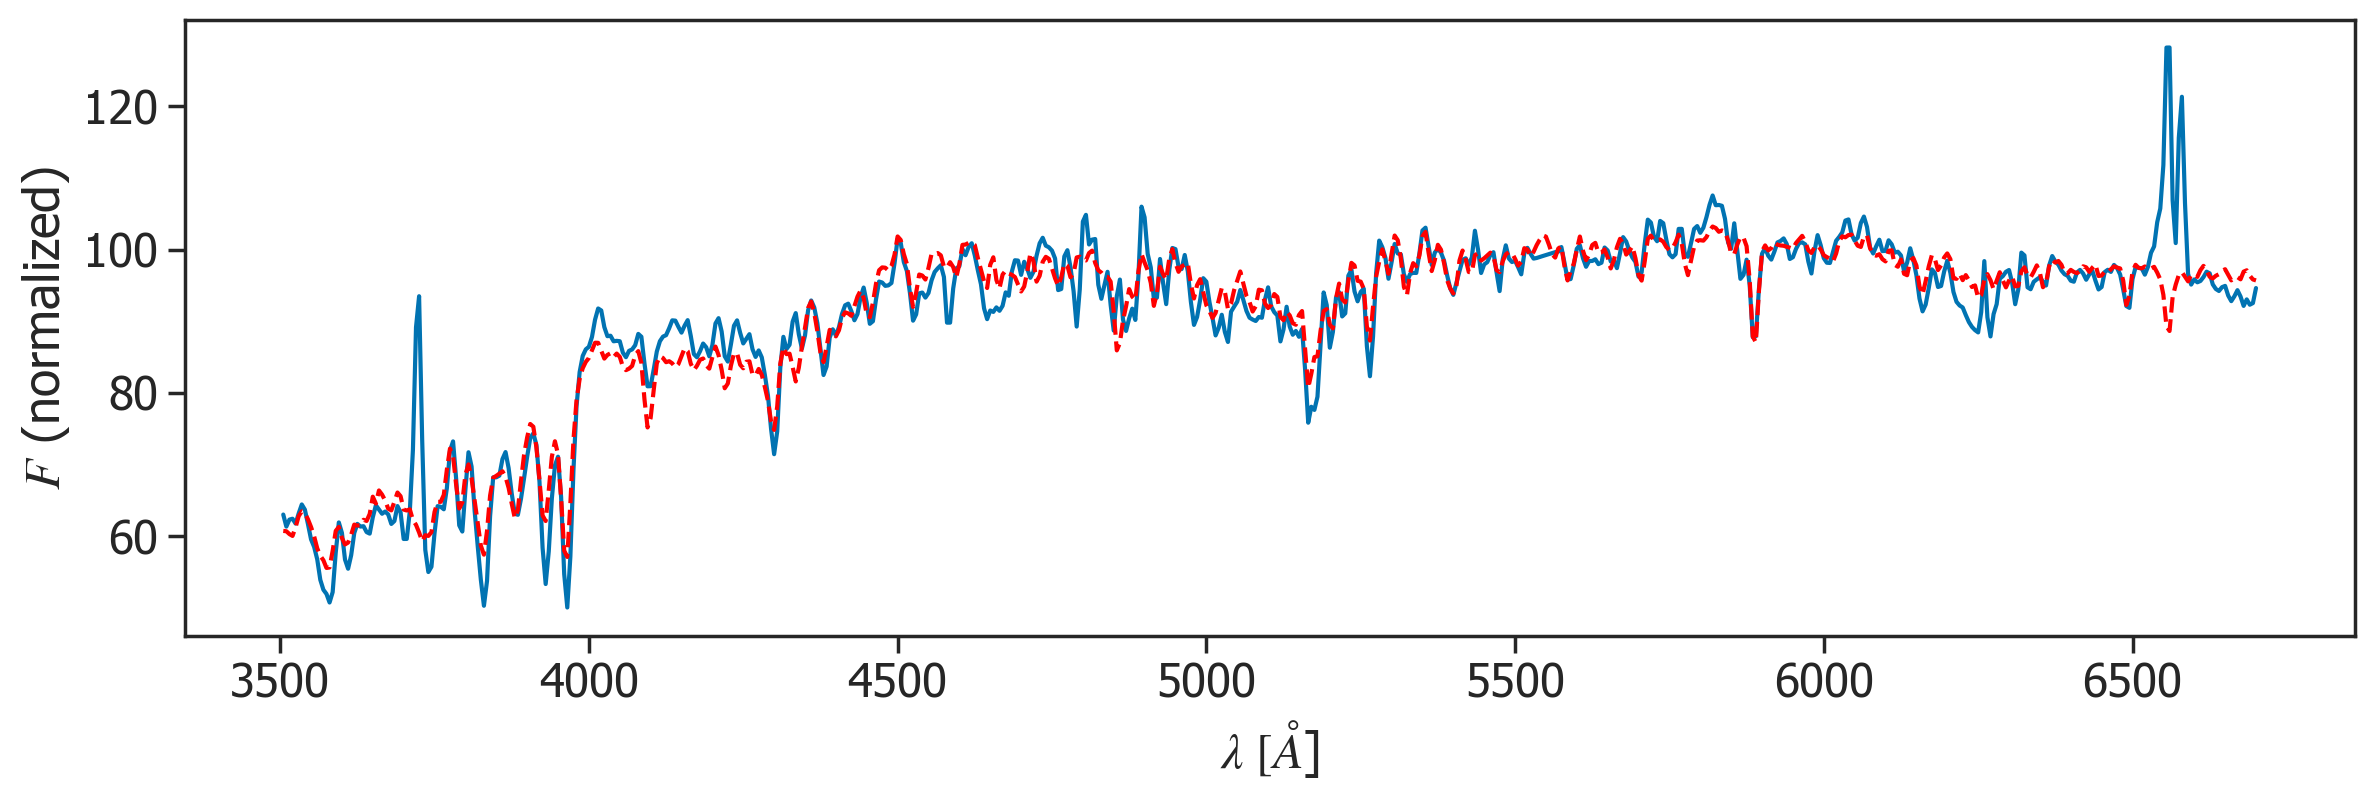

In [5]:
X = np.array(stellar_spectra).T
Y = NGC3512["flam"]

# Performing linear regression
regressor = LinearRegression(positive=True)
regressor.fit(X, Y)
gal_model = regressor.intercept_+np.sum(X*regressor.coef_, axis=1)
print(regressor.coef_/sum(regressor.coef_))

fig = plt.figure(figsize=(14, 4)); ax = plt.subplot()
ax.plot(NGC3512["lam"], Y, label="Observed Spectrum")
ax.plot(NGC3512["lam"], gal_model, color="red", ls="--", label="Modeled Spectrum")
ax.set_xlabel(r'$\lambda~[\AA$]')
ax.set_ylabel(r"$F$ (normalized)")



Unarguably, this is a reasonable spectral fit. But is this the best we can do? Can you think of a few caveats of using such a simple method?

To name a few:
* Line velocity dispersions and absorption line depths can be modeled better. 

* There are very clear OII and H$\alpha$ emission line complexes, which are not yet modeled.

This looks like a great time to dive into more sophisticated, state-of-the-art spectral analyses software, such as [pPXF](https://pypi.org/project/ppxf/). Considering galaxies as pure stellar systems, the spectrum observed at a certain sky position is a (luminosity-weighted) sum of individual stellar spectra redshifted according to their line-of-sight velocities. If one makes the assumption that the spectrum of all stars is given by a single template, then it simply reduces to the convolution between that spectrum and the line-of-sight velocity distribution (LOSVD), which can then be retrieved by solving the inverse problem, i.e., deconvolving the spectra using the template.

# Penalized Pixel-Fitting (pPXF) Method

The **penalized pixel-fitting (pPXF)** method [(Cappellari & Emsellem 2004)](https://iopscience.iop.org/article/10.1086/381875/meta) is a widely used technique to extract stellar kinematics and LOSVDs from galaxy spectra. The parametric recovery of the LOSVD in pixel space starts with creating a model galaxy spectrum $G_{\text{mod}}(x)$ by convolving a template spectrum $T(x)$ by a parametrized LOSVD. Both the object and the template spectra are rebinned in wavelength to a linear scale in $x = \ln \lambda$, while usually preserving the number of spectral pixels. The best-fitting parameters of the LOSVD are determined by minimizing the $\chi^2$, which measures the agreement between the model and the observed galaxy spectrum $G(x)$ over the set of $N$ good pixels:

$\chi^2 = \sum_{n=1}^N \left( \frac{G(x_n) - G_{\text{mod}}(x_n) }{\Delta G (x_n)} \right)^2,$

where $\Delta G (x_n)$ is the measurement error on the observed spectrum $G(x_n)$. The observed galaxy spectrum at logarithmic wavelength $x = \ln \lambda$ can be modeled as:

$ G_{\text{mod}}(x) = \sum_{k=1}^K w_k \, \big[B \ast T_k\big](x) \; + \; \sum_{l=0}^L b_l P_l(x),$

where:
- $ T_k(x) $: library of $K$ stellar spectrum templates,  
- $ B(x) $: line broadening function = LOSVD $ \mathcal{L}(v) $,  
- $ w_k \geq 0 $: template weights,  
- $ P_\ell(x) $: Legendre polynomials of order $\ell$ to absorb continuum mismatch,  
- $ \ast $: convolution.  

The LOSVD can be expanded as a **Gauss–Hermite series** (van der Marel & Franx 1993; Gerhard 1993):

$\mathcal{L}(v) = \frac{1}{\sigma \sqrt{2\pi}} \, e^{-\frac{1}{2} y^2} \left[ 1 + \sum_{m=3}^M h_m H_m(y) \right],$

where
- $ y = \frac{v - V}{\sigma} $,  
- $ V $: mean velocity,  
- $ \sigma $: velocity dispersion,  
- $ h_m $: Gauss–Hermite coefficients (measure deviations from Gaussian: $ h_3 $ skewness, $ h_4 $ kurtosis, …),  
- $ H_m $: Hermite polynomials.

With these definitions the minimization of the chi-squared $\chi^2$ is a nonlinear least-squares optimization problem. When data are noisy or undersampled, higher-order moments ($ h_m $) can be unreliable. pPXF uses a **penalty term** that biases the solution toward a pure Gaussian when deviations are not significant:

$ \chi^2_p = \chi^2 + \alpha \mathcal{P}, $

where the penalty $ \mathcal{P} $ measures deviation from Gaussian:

$ D^2 \approx \sum_{m=3}^M h_m^2, \qquad \mathcal{P} \propto D^2. $

In practice, the residuals are perturbed:

$ r'_n = r_n + \lambda \, \sigma(r) \, D, $

with variance

$ \sigma^2(r) = \frac{1}{N} \sum_{n=1}^N r_n^2. $

This makes the effective objective function:

$ \chi^2_p \approx \chi^2 \, (1 + \lambda^2 D^2),$

so non-Gaussian solutions are only accepted if they improve the fit significantly.


#### Algorithm Summary

1. Start with an initial guess $(V, \sigma, h_m=0)$.  
2. Solve for template weights and polynomials linearly.  
3. Compute residuals.  
4. Perturb residuals with the penalty.  
5. Use nonlinear least-squares (Levenberg–Marquardt) to update $(V, \sigma, h_m)$.  
6. Iterate until convergence.  


#### Key Features

- Works directly in pixel space (flexible with masks, emission lines).  
- Extracts robust kinematics $(V, \sigma, h_m)$ even at low S/N.  
- Penalization ensures that only statistically significant non-Gaussian features are preserved.  

Alright! Now, given this background, lets test our knowledge with an example FRB host galaxy, which we lovingly call as "FRB Mizu".

In [6]:
# read in the spectrum
spectrum_file = "data/spectrum_mizu.csv"
data = pd.read_csv(spectrum_file)
flux, flux_unc, lam_obs = data["flux"], data["flux_unc"], data["wavelen"]
mask = np.logical_not(np.logical_or(np.isnan(flux), np.isnan(flux_unc)))
mask = np.logical_and(mask, flux_unc>0)
flux, flux_unc = flux[mask], flux_unc[mask]
lam_obs = lam_obs[mask]


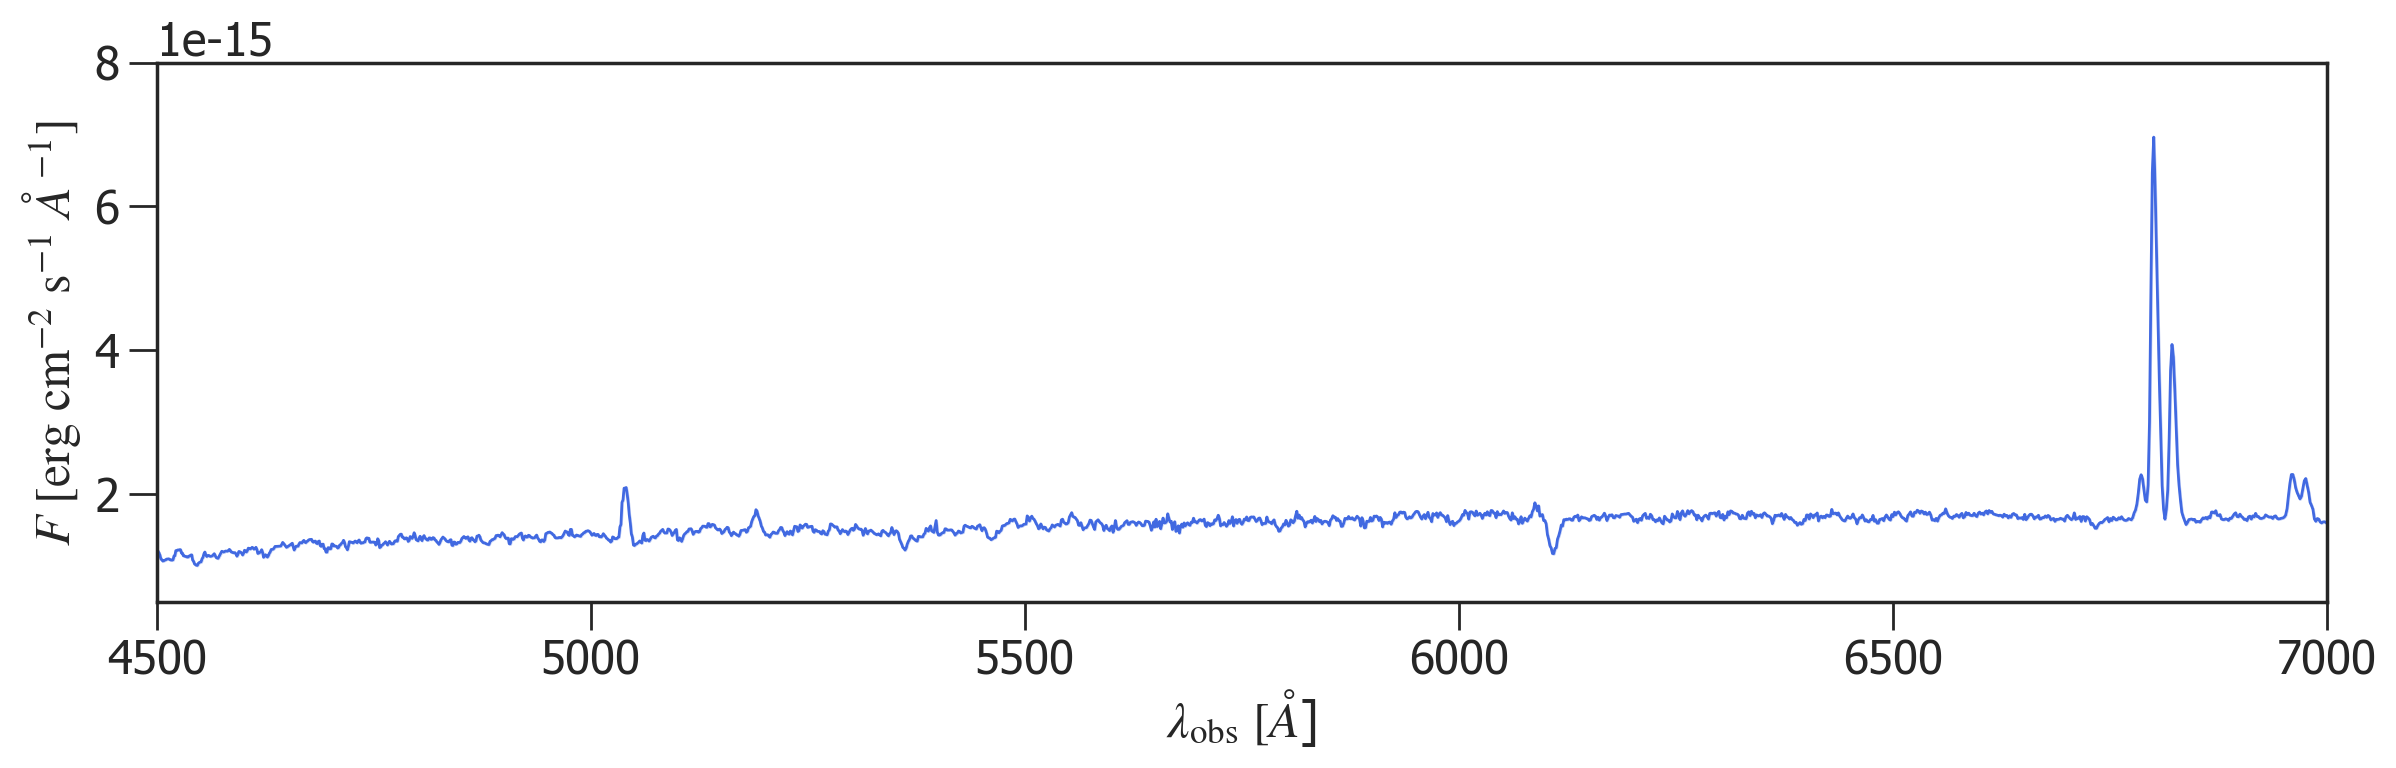

In [7]:
# plot the spectrum
fig = plt.figure(figsize=(14, 3.5)); ax = plt.subplot()

ax.plot(lam_obs, flux, color="royalblue", linewidth=1, linestyle="solid", label="Observed Data")
ax.fill_between(lam_obs, (flux-flux_unc), (flux+flux_unc), color="royalblue", alpha=0.2)

ax.set_xlabel(r'$\lambda_\mathrm{{obs}}~[\AA$]', labelpad=1)
ax.set_ylabel(r"$F~[\mathrm{erg}~\mathrm{cm}^{-2}~\mathrm{s}^{-1}~\AA^{-1}]$")

ax.set_xlim([4500, 7000])
ax.set_ylim(0.5e-15, 8e-15)

ax.tick_params(direction='out', length=6, width=1)
ax.tick_params(which='both', width=1)
ax.tick_params(which='major', length=10)
ax.tick_params(which='minor', length=4)


Again, you must be able to spot some prominent emission line features, like the H$\alpha$ complex and the SII doublet. Can you guess what the approximate redshift of this galaxy might be? (Hint: overlay the rest-frame wavelengths of emission line galaxies and try to match them to observed wavelengths.)

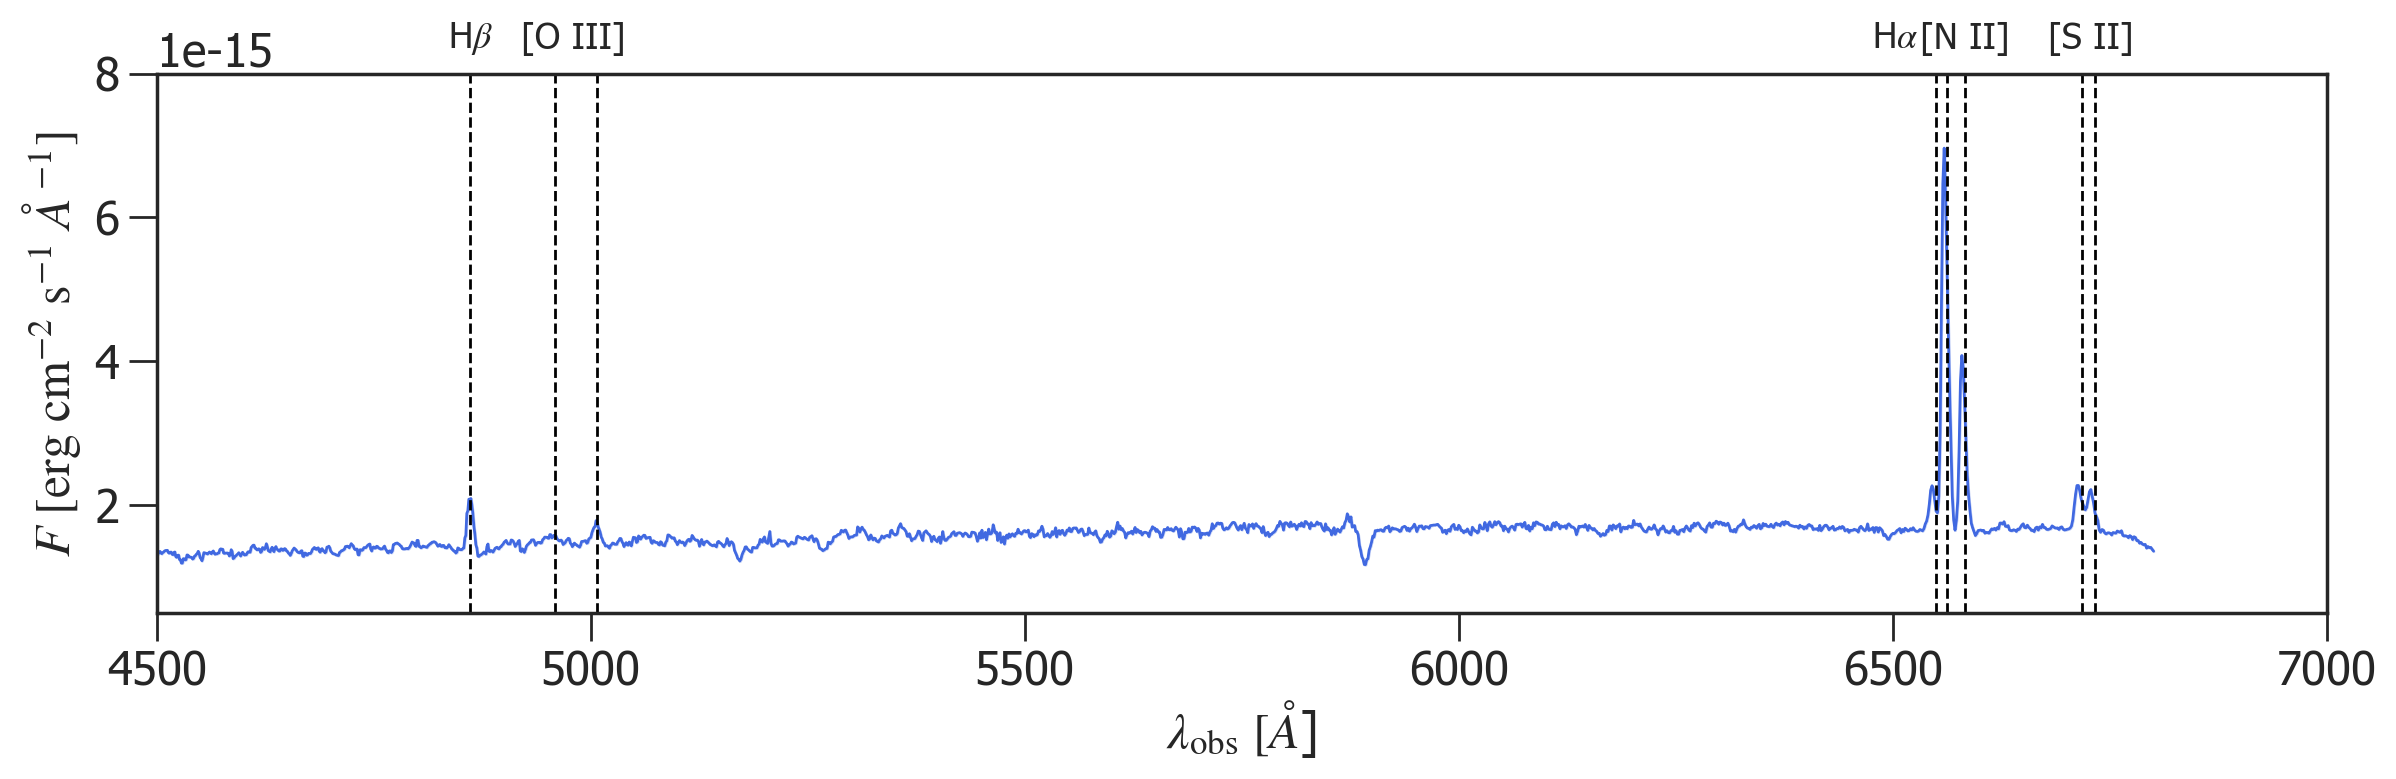

In [8]:
z = 0.0368
lam = lam_obs/(1+z)

fig = plt.figure(figsize=(14, 3.5)); ax = plt.subplot()

ax.plot(lam, flux, color="royalblue", linewidth=1, linestyle="solid", label="Observed Data")
ax.fill_between(lam, (flux-flux_unc), (flux+flux_unc), color="royalblue", alpha=0.2)

ax.set_xlabel(r'$\lambda_\mathrm{{obs}}~[\AA$]', labelpad=1)
ax.set_ylabel(r"$F~[\mathrm{erg}~\mathrm{cm}^{-2}~\mathrm{s}^{-1}~\AA^{-1}]$")

ax.set_xlim([4500, 7000])
ax.set_ylim(0.5e-15, 8e-15)

ax.tick_params(direction='out', length=6, width=1)
ax.tick_params(which='both', width=1)
ax.tick_params(which='major', length=10)
ax.tick_params(which='minor', length=4)

label_loc = 8.5e-15

ax.text(4861.35, label_loc, r'H$\beta$', ha='center', va='center', fontsize=13)
ax.axvline(4861.35, linestyle="--", color="black", linewidth=1)

ax.text(4980, label_loc, '[O III]', ha='center', va='center', fontsize=13)
ax.axvline(4958.911, linestyle="--", color="black", linewidth=1)
ax.axvline(5006.843, linestyle="--", color="black", linewidth=1)

ax.text(6718.29+10, label_loc, '[S II]', fontsize=13, ha='center', va='center')
ax.axvline(6718.29, linestyle="--", color="black", linewidth=1)
ax.axvline(6732.67, linestyle="--", color="black", linewidth=1)

ax.text(6562.8-60, label_loc, r'H$\alpha$', fontsize=13, ha='center', va='center')
ax.axvline(6562.8, linestyle="--", color="black", linewidth=1)

ax.text(6583, label_loc, r'[N II]', fontsize=13, ha='center', va='center')
ax.axvline(6549.86, linestyle="--", color="black", linewidth=1)
ax.axvline(6583, linestyle="--", color="black", linewidth=1)


In [9]:
# Normalize spectrum to avoid numerical issues
norm = np.median(flux)
flux = flux/norm
flux_unc = flux_unc/norm
rms = np.median(flux_unc)

# Logarithmically rebin the data
flux, loglam, velscale = util.log_rebin(lam, flux)
lam = np.exp(loglam)
noise = np.abs(flux_unc)


In [10]:
R = 800 # Resolving power of LRIS

# Compute the spectral resolution in wavelength units assuming it is approximately constant
# Spectral resolution FWHM is given by the definition of resolving power, and using as reference the geometric 
# mean of the observed wavelength range
# Observed wavelength range of LRIS: 0.39–1.1 microns

FWHM_gal = 1e4*np.sqrt(0.39*1.1)/R
print( f"FWHM_gal: {FWHM_gal:.1f} Å")

# Since we have deredshifted the spectra, we need to correct the instrumental dispersion as well
FWHM_gal /= (1 + z)     # Adjust resolution in Angstrom
print(f"de-redshifted FWHM_gal: {FWHM_gal:.1f} Å")

# Compute the instrumental dispersion
c = 299792.458 # speed of light in km/s
sigma_inst = c/(R*np.sqrt(4*np.log(4)))
print( f"sigma_inst: {sigma_inst:.0f} km/s")

velscale = velscale[0]
print(f"Velocity scale per pixel: {velscale:.2f} km/s")


FWHM_gal: 8.2 Å
de-redshifted FWHM_gal: 7.9 Å
sigma_inst: 159 km/s
Velocity scale per pixel: 71.25 km/s


In [11]:
# Set up spectral templates
FWHM_temp = 2.51   # Resolution of E-MILES templates in the fitted range
ppxf_dir = path.dirname(path.realpath(lib.__file__))
pathname = ppxf_dir + '/miles_models/Eun1.30*.fits'

# The templates are normalized to the V-band using norm_range
# In this way the weights returned by pPXF represent V-band light fractions of each SSP
# Limit the age of the templates to the age of universe at z.
miles = lib.miles(pathname, 
                  velscale, 
                  norm_range=[5070, 5950], 
                  age_range=[0, cosmo.age(z*cu.redshift).value])

# The stellar templates are reshaped below into a 2-dim array with each spectrum as a column, however 
# we save the original array dimensions reg_dim, which are needed to specify the regularization dimensions
reg_dim = miles.templates.shape[1:]
stars_templates = miles.templates.reshape(miles.templates.shape[0], -1)


In [12]:
# The emission_lines function defines the most common lines, but additional lines can be included by editing 
# the function in the file ppxf_util.py
lam_range_gal = np.asarray([np.min(lam), np.max(lam)])
gas_templates, gas_names, line_wave = util.emission_lines(miles.ln_lam_temp, 
                                                          lam_range_gal, 
                                                          FWHM_gal, 
                                                          tie_balmer=0)

# Combine the stellar and gaseous templates into a single array
# During the pPXF fit they will be assigned a different kinematic component value
templates = np.column_stack([stars_templates, gas_templates])


Emission lines included in gas templates:
['Hgamma' 'Hbeta' 'Halpha' '[SII]6716' '[SII]6731' 'HeII4687' 'HeI5876'
 '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']


In [13]:
# Setup pPXF parameters

# As the spectrum was deredshifted, the starting guess for the velocity becomes close to zero
start = [0, sigma_inst] # (km/s), starting guess for [V, sigma]

# Fit two kinematics components, one for the stars and one for the gas
# Assign component=0 to the stellar templates, component=1 to the gas
n_stars = stars_templates.shape[1]
n_gas = len(gas_names)
component = [0]*n_stars + [1]*n_gas
gas_component = np.array(component) > 0  # gas_component=True for gas templates

# Fit (V, sig) moments=2 for both the stars and the gas
moments = [2, 2]

# Adopt the same starting value for both the stars and the gas components
start = [start, start]


 Best Fit:       Vel     sigma
 comp.  0:       -20       185
 comp.  1:      -131        59
Stars Attenuation A_V: 0.191
  Gas Attenuation A_V: 8.000
chi2/DOF: 2.253e+04; DOF: 2013; degree = 4; mdegree = 8
method = capfit; Jac calls: 11; Func calls: 174; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 10/154
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component           name        flux       err      V     sig
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Comp:  1                Hgamma      2.180   0.00097    -131    59
Comp:  1                 Hbeta      4.333   0.00080    -131    59
Comp:  1                Halpha      19.95   0.00056    -131    59
Comp:  1             [SII]6716      2.647   0.00082    -131    59
Comp:  1             [SII]6731      2.368   0.00080    -131    59
Comp:  1              HeII4687     0.1590   0.00083    -131    59
Comp:  1               HeI5876     0.5080   0.00091    -131    59
Comp:  1       

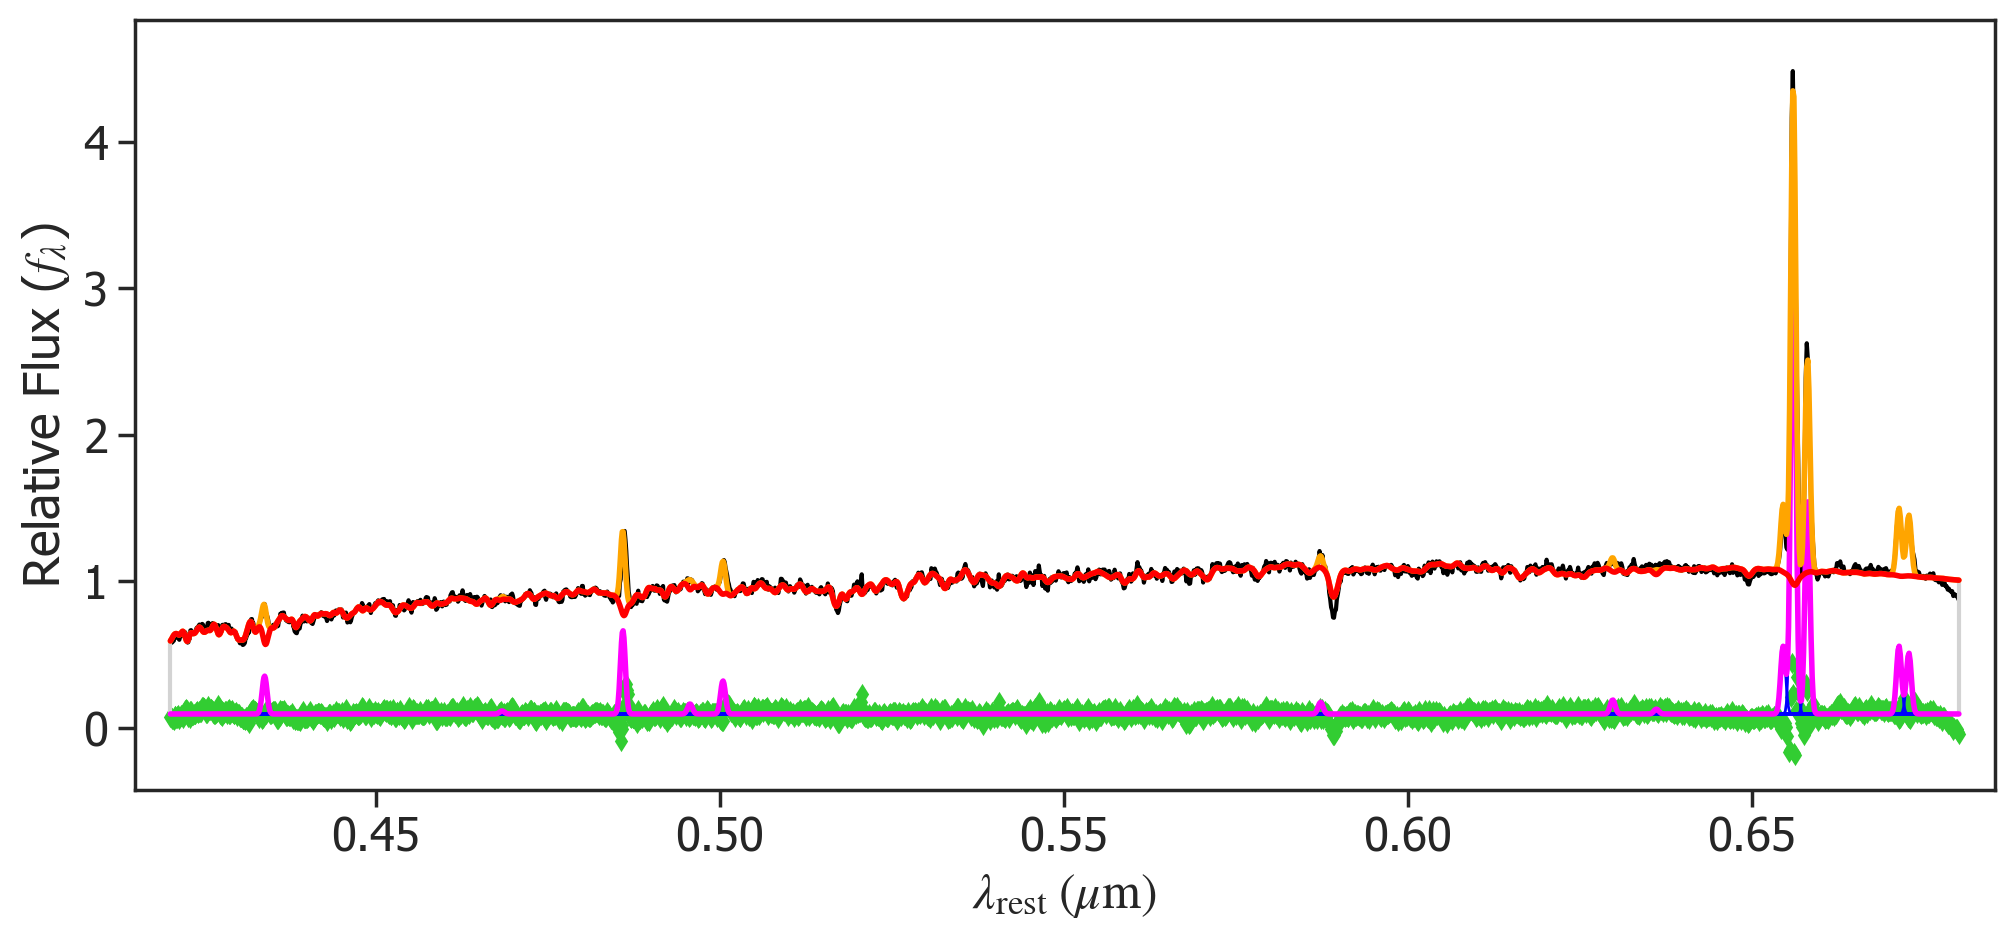

In [14]:
pp = ppxf(templates, np.array(flux), np.array(noise), velscale, start,
          moments=moments, degree=4, mdegree=8, lam=lam, lam_temp=miles.lam_temp, regul=100,
          reg_dim=reg_dim, component=component, gas_component=gas_component, reddening=0, 
          gas_reddening=0, gas_names=gas_names, goodpixels=np.arange(flux.size))
plt.figure(figsize=(12, 5))
pp.plot()


In [15]:
# As the templates have larger instrumental dispersion than the galaxy spectrum, and for this reason it was 
# not possible to match the resolutions of the templates before the fit, we now need to correct the fitted 
# sigma by the quadratic differences in instrumental resolutions.

lam_med = np.median(lam)  # Angstrom
sigma_gal = c*FWHM_gal/lam_med/2.355  # in km/s
sigma_temp = c*FWHM_temp/lam_med/2.355
sigma_obs = pp.sol[0][1]   # sigma is second element of first kinematic component
sigma_diff2 = sigma_gal**2 - sigma_temp**2   # eq. (5) of Cappellari (2017)
sigma = np.sqrt(sigma_obs**2 - sigma_diff2)
print(f"sigma stars corrected: {sigma:.0f} km/s")

# Uncertainties on stellar kinematics. More accurate ones can be obtained with bootstrapping.
errors = pp.error[0]*np.sqrt(pp.chi2) # assume the fit is good
print("Formal errors:")
print("   dV   dsigma")
print("".join("%6.2g" % f for f in errors))

# An improved estimate of the best-fitting redshift is given by the following lines using equation 5 of 
# Cappellari (2022).
errors = pp.error[0]*np.sqrt(pp.chi2) 
vpec = pp.sol[0][0]                         # This is the fitted residual velocity in km/s
znew = (1 + z)*np.exp(vpec/c) - 1           # eq.(5c) Cappellari (2022)
dznew = (1 + z)*errors[0]/c                 # eq.(5d) Cappellari (2022)
print(f"Best-fitting redshift z = {znew:#.6f} +/- {dznew:#.2g}")


sigma stars corrected: 51 km/s
Formal errors:
   dV   dsigma
    10    11
Best-fitting redshift z = 0.036729 +/- 3.5e-05


In [16]:
flux_measurements = {}
for i in range(len(pp.gas_names)):
    flux_measurements[pp.gas_names[i]] = norm*pp.gas_flux[i]
    flux_measurements["{}_err".format(pp.gas_names[i])] = norm*pp.gas_flux_error[i]

flux_measurements

{'Hgamma': 3.3860912304347345e-15,
 'Hgamma_err': 1.511450358509427e-18,
 'Hbeta': 6.7315496984614755e-15,
 'Hbeta_err': 1.2404437596873964e-18,
 'Halpha': 3.09972851279295e-14,
 'Halpha_err': 8.774625344502196e-19,
 '[SII]6716': 4.1120391311661855e-15,
 '[SII]6716_err': 1.2801805924126896e-18,
 '[SII]6731': 3.678179196362318e-15,
 '[SII]6731_err': 1.2420434555054818e-18,
 'HeII4687': 2.46944373074166e-16,
 'HeII4687_err': 1.283827559868403e-18,
 'HeI5876': 7.890961484249525e-16,
 'HeI5876_err': 1.4126148180481551e-18,
 '[OIII]5007_d': 3.379664791264948e-15,
 '[OIII]5007_d_err': 1.5804109849114422e-18,
 '[OI]6300_d': 1.1928413256687113e-15,
 '[OI]6300_d_err': 1.4936368242872385e-18,
 '[NII]6583_d': 1.7380750271192685e-14,
 '[NII]6583_d_err': 1.1124415225190785e-18}

# Dominant ionization mechanism

The Baldwin, Phillips \& Terlevich empirical optical emission-line diagnostic diagrams using the optical line ratios [OI]/H$\alpha$, [SII]/H$\alpha$, [NII]/H$\alpha$, and [OIII]/H$\beta$ [(Baldwin, Phillips, & Terlevich (1981))](https://iopscience.iop.org/article/10.1086/130766) is used to distinguish between different ionization sources in galaxies. Over time, several key works established the dividing lines that are now standard references:

* [Kewley+2001](https://iopscience.iop.org/article/10.1086/321545) --- **Maximum starburst line**: Using detailed photoionization models of star-forming galaxies, they derived an upper theoretical limit to the line ratios that pure stellar photoionization can produce. Galaxies above this **solid line** cannot be explained by star formation alone and must host an additional ionizing source, typically an AGN.

* [Kauffmann+2003](https://academic.oup.com/mnras/article/346/4/1055/1062435?login=true) --- **Empirical star-forming vs. composite division**: Analyzing SDSS galaxies, they found that many objects lie just below the Kewley+2001 line but still show signs of AGN activity. They introduced a more relaxed **dashed line** boundary: galaxies below this line are dominated by pure star formation, while those between the Kauffmann and Kewley lines are "composite" systems with contributions from both star formation and AGN.

* [Kewley+2006](https://academic.oup.com/mnras/article/372/3/961/972572?login=true) --- **Seyfert vs. LINER classification**: Extending the BPT classifications, they provided an empirical separation between Seyferts (higher ionization, harder spectra) and LINERs (lower ionization, often associated with older stellar populations or weaker AGN). This **dotted line** divides the AGN branch of the BPT diagram into its two main sub-classes.


In [17]:
# Reading in SDSS emission line fluxes
bptdat = pd.read_csv("data/SDSS_BPT.csv")
snr_thresh = 10
mask1 = np.logical_and(bptdat["oiii_5007_flux"]/bptdat["oiii_5007_flux_err"]>snr_thresh,
                      bptdat["h_beta_flux"]/bptdat["h_beta_flux_err"]>snr_thresh)
mask2 = np.logical_and(bptdat["nii_6584_flux"]/bptdat["nii_6584_flux_err"]>snr_thresh,
                      bptdat["h_alpha_flux"]/bptdat["h_alpha_flux_err"]>snr_thresh)
mask3 = np.logical_and(bptdat["sii_6717_flux"]/bptdat["sii_6717_flux_err"]>snr_thresh,
                      bptdat["sii_6731_flux"]/bptdat["sii_6731_flux_err"]>snr_thresh)
mask4 = bptdat["oi_6300_flux"]/bptdat["oi_6300_flux_err"]>snr_thresh
mask = np.logical_and(mask1, mask2); mask = np.logical_and(mask, mask3); mask = np.logical_and(mask, mask4)

bptdat = bptdat[mask].reset_index()

bptdat.head()


,index,specObjID,oiii_4959_flux,oiii_4959_flux_err,oiii_5007_flux,oiii_5007_flux_err,h_beta_flux,h_beta_flux_err,nii_6548_flux,nii_6548_flux_err,nii_6584_flux,nii_6584_flux_err,h_alpha_flux,h_alpha_flux_err,sii_6717_flux,sii_6717_flux_err,sii_6731_flux,sii_6731_flux_err,oi_6300_flux,oi_6300_flux_err
0,91,299503421340280832,32.83901,3.867179,95.84792,4.246964,257.9409,4.885870,186.80880,2.018863,563.4586,6.089350,1151.2110,9.593594,194.4022,4.352325,153.68080,4.440993,32.05777,3.175750
1,95,299504245974001664,47.49470,2.931503,203.21100,8.831159,194.0930,3.757110,127.59600,1.567992,384.8589,4.729420,919.3564,8.633987,140.5348,3.134246,110.58970,2.835191,30.05624,2.113387
2,104,299505894771681280,39.45840,2.905433,131.32030,6.475480,192.5399,3.768797,116.24740,1.677521,350.6291,5.059785,863.9615,8.067708,136.0053,3.368287,105.14760,3.291207,31.44542,2.312924
3,143,299511667207727104,21.30112,2.355875,47.01003,2.834701,115.5547,2.989640,61.75349,1.005389,186.2628,3.032482,615.6885,5.857655,117.1578,2.750722,82.45193,2.511887,19.10643,1.868355
4,156,299513316944930816,13.54014,2.415372,51.88348,2.842988,117.5592,3.160311,62.19669,0.991653,187.5996,2.991050,625.9243,5.773787,125.9418,2.783081,82.95983,2.508759,22.94478,1.862804


In [18]:
log_NII_Halpha1 = np.linspace(-1.2, 0, 100); log_NII_Halpha2 = np.linspace(-2, 0.3, 100)
log_SII_Halpha1 = np.linspace(-1.5, 0.2, 100); log_SII_Halpha2 = np.linspace(-0.31, 1, 100)
log_OI_Halpha1 = np.linspace(-2.5, -0.75, 100); log_OI_Halpha2 = np.linspace(-1.13, 0, 100)
                                                                                                                                                                                                                                                                                                                                 
# BPT classification lines
# Kewley+2001 maximum starburst line
log_OIII_Hbeta_Ke01 = (0.61/(log_NII_Halpha1-0.05)) + 1.3

# Kauffmann+2003 star-forming galaxies vs Seyfert-H II composite objects classification line
log_OIII_Hbeta_Ka03_1 = (0.61/(log_NII_Halpha2-0.47)) + 1.19
log_OIII_Hbeta_Ka03_2 = (0.72/(log_SII_Halpha1-0.32)) + 1.3
log_OIII_Hbeta_Ka03_3 = (0.73/(log_OI_Halpha1+0.59)) + 1.33

# Kewley+2006 Seyfert vs LINER classification lines
log_OIII_Hbeta_Ke03_1 = (1.89*log_SII_Halpha2)+0.76
log_OIII_Hbeta_Ke03_2 = (1.18*log_OI_Halpha2)+1.30


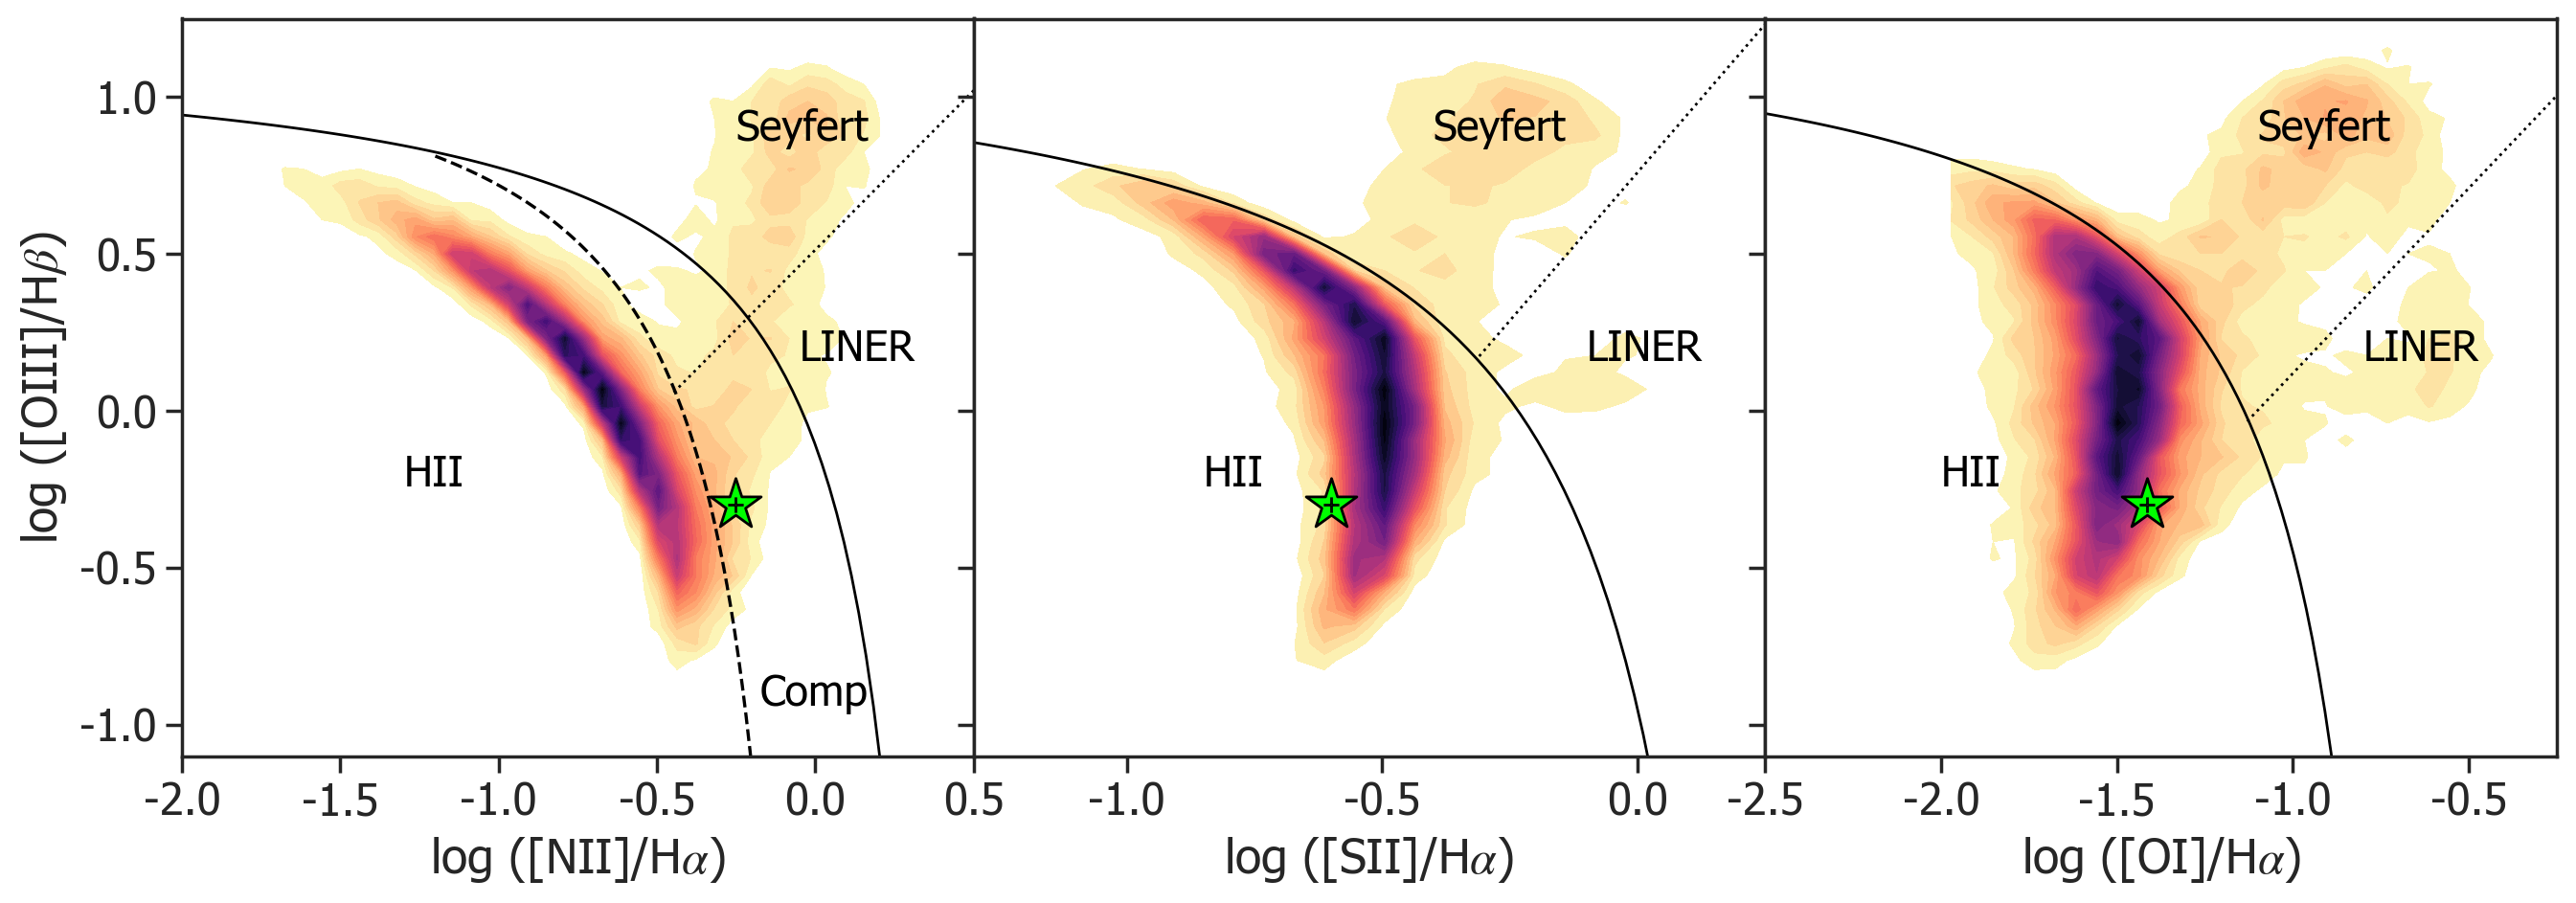

In [19]:
# creating a custom colormap
cmap = matplotlib.cm.get_cmap('magma_r')
colors = ["white", "white", "white"]+[cmap(i/100) for i in range(100)]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)

# plotting the BPT diagram
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 5), sharey=True)
fig.subplots_adjust(wspace=0)

# panel-1: [NII]/Halpha vs [OIII]/Hbeta
counts, xedges, yedges = np.histogram2d(np.log10(bptdat["nii_6584_flux"]/bptdat["h_alpha_flux"]),
                                        np.log10(bptdat["oiii_5007_flux"]/bptdat["h_beta_flux"]),
                                        bins=(50, 50), range=[[-2, 0.95], [-1.2, 1.5]])
xs, ys = [], []
for i in range(len(xedges)-1):
    xs.append((xedges[i]+xedges[i+1])/2), ys.append((yedges[i]+yedges[i+1])/2)
mplt = ax[0].contourf(xs, ys, counts.transpose(), 30, cmap=cmap)

ax[0].plot(log_NII_Halpha1, log_OIII_Hbeta_Ke01, color="black", linewidth=1.2, linestyle="--")
ax[0].plot(log_NII_Halpha2, log_OIII_Hbeta_Ka03_1, color="black", linewidth=1, linestyle="solid")
ax[0].plot([-0.4467637356387215, 0.7464452280741671], [0.05932203389830515, 1.2711864406779658], color="black", linewidth=1, linestyle="dotted")

ax[0].set_xlim(-2, 0.5); ax[0].set_ylim(-1.1, 1.25)
ax[0].set_xlabel(r'log ([NII]/H$\alpha$)'); ax[0].set_ylabel(r'log ([OIII]/H$\beta$)')
ax[0].text(-1.3, -0.2, 'HII', color="black", ha='left', va='center', fontsize=16)
ax[0].text(-0.175, -0.9, 'Comp', color="black", ha='left', va='center', fontsize=16)
ax[0].text(-0.25, 0.9, 'Seyfert', color="black", ha='left', va='center', fontsize=16)
ax[0].text(-0.05, 0.2, 'LINER', color="black", ha='left', va='center', fontsize=16)

# ------------------------------------------------------------------------------------------------------------------------

# panel-2: [SII]/Halpha vs [OIII]/Hbeta
counts, xedges, yedges = np.histogram2d(np.log10((bptdat["sii_6717_flux"]+bptdat["sii_6731_flux"])/bptdat["h_alpha_flux"]),
                                        np.log10(bptdat["oiii_5007_flux"]/bptdat["h_beta_flux"]),
                                        bins=(50, 50),
                                        range=[[-2, 0.95], [-1.2, 1.5]])
xs, ys = [], []
for i in range(len(xedges)-1):
    xs.append((xedges[i]+xedges[i+1])/2), ys.append((yedges[i]+yedges[i+1])/2)
mplt = ax[1].contourf(xs, ys, counts.transpose(), 30, cmap=cmap)

ax[1].plot(log_SII_Halpha1, log_OIII_Hbeta_Ka03_2, color="black", linewidth=1, linestyle="solid")
ax[1].plot(log_SII_Halpha2, log_OIII_Hbeta_Ke03_1, color="black", linewidth=1, linestyle="dotted")

ax[1].set_xlim(-1.3, 0.25)
ax[1].set_xlabel(r'log ([SII]/H$\alpha$)')
ax[1].text(-0.85, -0.2, 'HII', color="black", ha='left', va='center', fontsize=16)
ax[1].text(-0.4, 0.9, 'Seyfert', color="black", ha='left', va='center', fontsize=16)
ax[1].text(-0.1, 0.2, 'LINER', color="black", ha='left', va='center', fontsize=16)

# ------------------------------------------------------------------------------------------------------------------------

# panel-3: [OI]/Halpha vs [OIII]/Hbeta
counts, xedges, yedges = np.histogram2d(np.log10(bptdat["oi_6300_flux"]/bptdat["h_alpha_flux"]),
                                        np.log10(bptdat["oiii_5007_flux"]/bptdat["h_beta_flux"]),
                                        bins=(50, 50),
                                        range=[[-2, 0.95], [-1.2, 1.5]])
xs, ys = [], []
for i in range(len(xedges)-1):
    xs.append((xedges[i]+xedges[i+1])/2), ys.append((yedges[i]+yedges[i+1])/2)
mplt = ax[2].contourf(xs, ys, counts.transpose(), 30, cmap=cmap)

ax[2].plot(log_OI_Halpha1, log_OIII_Hbeta_Ka03_3, color="black", linewidth=1, linestyle="solid")
ax[2].plot(log_OI_Halpha2, log_OIII_Hbeta_Ke03_2, color="black", linewidth=1, linestyle="dotted")

ax[2].set_xlim(-2.5, -0.25)
ax[2].set_xlabel(r'log ([OI]/H$\alpha$)')
ax[2].text(-2, -0.2, 'HII', color="black", ha='left', va='center', fontsize=16)
ax[2].text(-1.1, 0.9, 'Seyfert', color="black", ha='left', va='center', fontsize=16)
ax[2].text(-0.8, 0.2, 'LINER', color="black", ha='left', va='center', fontsize=16)

# ------------------------------------------------------------------------------------------------------------------------

# Adding the FRB measurements
NII_Halpha = np.log10(flux_measurements["[NII]6583_d"]/flux_measurements["Halpha"])
NII_Halpha_err = ((flux_measurements["[NII]6583_d_err"]/flux_measurements["[NII]6583_d"]) + (flux_measurements["Halpha_err"]/flux_measurements["Halpha"]))
SII_Halpha = np.log10((flux_measurements["[SII]6716"]+flux_measurements["[SII]6731"])/flux_measurements["Halpha"])
SII_Halpha_err = ((np.sqrt(flux_measurements["[SII]6716_err"]**2 + flux_measurements["[SII]6731_err"]**2)/(flux_measurements["[SII]6716"]+flux_measurements["[SII]6731"]))) + (flux_measurements["Halpha_err"]/flux_measurements["Halpha"])
OI_Halpha = np.log10(flux_measurements["[OI]6300_d"]/flux_measurements["Halpha"])
OI_Halpha_err = 0.5*((flux_measurements["[OI]6300_d_err"]/flux_measurements["[OI]6300_d"]) + (flux_measurements["Halpha_err"]/flux_measurements["Halpha"]))
OIII_Hbeta = np.log10(flux_measurements["[OIII]5007_d"]/flux_measurements["Hbeta"])
OIII_Hbeta_err = (((flux_measurements["[OIII]5007_d_err"])/flux_measurements["[OIII]5007_d"]) + ((flux_measurements["Hbeta_err"])/flux_measurements["Hbeta"]))


marker, marker_size, color = "*", 400, "lime"
ax[0].errorbar(NII_Halpha, OIII_Hbeta, xerr=NII_Halpha_err, yerr=OIII_Hbeta_err, fmt=marker, color=color, alpha=0.75,
               capsize=3, ecolor="black", elinewidth=0.5, markeredgecolor="black", markersize=1)
im = ax[0].scatter(NII_Halpha, OIII_Hbeta,  color=color, alpha=1, norm=matplotlib.colors.LogNorm(),
                   marker=marker, s=marker_size, edgecolors='black')

ax[1].errorbar(SII_Halpha, OIII_Hbeta, xerr=SII_Halpha_err, yerr=OIII_Hbeta_err, fmt=marker, ecolor="black", 
               elinewidth=0.5, color=color, alpha=0.75, capsize=3, markeredgecolor="black", markersize=1)
im = ax[1].scatter(SII_Halpha, OIII_Hbeta, c=color, norm=matplotlib.colors.LogNorm(), 
                   marker=marker, s=marker_size, edgecolors='black')

ax[2].errorbar(OI_Halpha, OIII_Hbeta, xerr=OI_Halpha_err, yerr=OIII_Hbeta_err, fmt=marker, ecolor="black", 
               elinewidth=0.5, color=color, alpha=0.75, capsize=3, markeredgecolor="black", markersize=1)
im = ax[2].scatter(OI_Halpha, OIII_Hbeta, c=color, norm=matplotlib.colors.LogNorm(),
                   marker=marker, s=marker_size, edgecolors='black')


# Star Formation Rate

pPXF provides emission-line flux measurements after properly modeling the stellar continuum and Balmer absorption. Using these measurements, one can derive a dust-corrected H$\alpha$ star formation rate (SFR). The key ingredient is the **Balmer decrement**, i.e. the observed flux ratio of H$\alpha$ and H$\beta$, which encodes the amount of reddening due to dust.

From the measured line fluxes $F_{H\alpha}$ and $F_{H\beta}$, we compute the **observed Balmer decrement** 

$D_{\rm obs} \;=\; \frac{F_{H\alpha}}{F_{H\beta}}$.

In the absence of dust, Case B recombination predicts an intrinsic ratio $D_{\rm int} \;\approx\; 2.86$, valid for an electron temperature $T_e \sim 10^4\ \mathrm{K}$ and density $n_e \sim 100\ \mathrm{cm^{-3}}$. Dust increases the observed Balmer decrement above the intrinsic value. Using an extinction law with coefficients $k(\lambda) = A_\lambda / E(B-V)$, the color excess of the gas can be written as

$E(B-V) \;=\; \frac{2.5}{k(H\beta) - k(H\alpha)} \log_{10}\!\left( \frac{D_{\rm obs}}{D_{\rm int}} \right)$.

For the Cardelli--O'Donnell law with $R_V=3.1$, the coefficients are
$k(H\alpha) \approx 2.535$ and $k(H\beta) \approx 3.609$, so that $k(H\beta) - k(H\alpha) \;\approx\; 1.074$.

The **attenuation** at the H$\alpha$ wavelength is 

$A_{H\alpha} = k(H\alpha)\,E(B-V)$.

The extinction-corrected H$\alpha$ flux is obtained by

$F_{H\alpha}^{\rm corr} = F_{H\alpha}^{\rm obs}\; 10^{0.4\,A_{H\alpha}}.$

Given the luminosity distance $D_L(z)$ at redshift $z$, $L_{H\alpha} = 4\pi D_L^2 \, F_{H\alpha}^{\rm corr}.$

**Kennicutt (1998)** provides a widely used calibration between H$\alpha$ luminosity and star formation rate (assuming a Salpeter IMF):
$
\mathrm{SFR}_{\rm Salpeter}\; \left[ M_\odot\,\mathrm{yr}^{-1}\right] 
= 7.9 \times 10^{-42}\,
L_{H\alpha}\; \left[\mathrm{erg\,s^{-1}}\right].
$

If a Chabrier IMF is preferred, the conversion factor is typically reduced by $\sim 1.7$:

$
\mathrm{SFR}_{\rm Chabrier} \approx 
\frac{\mathrm{SFR}_{\rm Salpeter}}{1.7}.
$

#### Error propagation
For a quick error estimate, one can propagate the fractional errors on the observed fluxes through to the SFR. Denoting the fractional errors
$
\delta F_{H\alpha} = \frac{\sigma_{H\alpha}}{F_{H\alpha}}, 
\qquad
\delta F_{H\beta} = \frac{\sigma_{H\beta}}{F_{H\beta}},
$
the fractional error on the observed decrement is
$
\delta D = \sqrt{ \delta F_{H\alpha}^2 + \delta F_{H\beta}^2 }.
$

The uncertainty in $E(B-V)$ follows from differentiating the equation above:
$
\sigma_{E(B-V)} = 
\frac{2.5}{\big(k(H\beta) - k(H\alpha)\big)\ln 10}
\;\frac{\delta D}{D_{\rm obs}}.
$

This propagates to an error in the corrected flux and therefore into the SFR.

#### Practical notes
* The intrinsic decrement $D_{\rm int}$ can vary: AGN or high-density gas may require values $\gtrsim 3.1$.
* The choice of extinction law (Cardelli, Calzetti, etc.) affects the result.
* Be aware of aperture losses and possible AGN contamination before interpreting the SFR.



In [20]:
# extinction curve constants for Cardelli+O'Donnell, Rv=3.1
k_Ha = 2.535
k_Hb = 3.609
k_diff = k_Hb - k_Ha      # ~1.074

# intrinsic Balmer ratio (case B)
D_int = 2.86
# --- compute Balmer decrement and E(B-V) ---
D_obs = flux_measurements["Halpha"]/flux_measurements["Hbeta"]
E_BV = (2.5 / k_diff) * np.log10(D_obs / D_int)    # Cardelli values used above
print("D_obs = {:.3f}, E(B-V) = {:.3f} mag".format(D_obs, E_BV))

# attenuation at Halpha
A_Ha = k_Ha * E_BV
print("A_Ha = {:.3f} mag".format(A_Ha))

# corrected Halpha flux
F_Ha_corr = flux_measurements["Halpha"] * 10**(0.4 * A_Ha)

# luminosity
D_L = cosmo.luminosity_distance(znew).to(u.cm).value
L_Ha = F_Ha_corr * 4 * np.pi * D_L**2   # if F in erg/s/cm^2 -> L in erg/s
print("L_Ha = {:.3e} erg/s".format(L_Ha))

# SFR: Kennicutt (1998) Salpeter
SFR_Salpeter = 7.9e-42 * L_Ha

# optionally convert to Chabrier (~divide by 1.7)
SFR_Chabrier = SFR_Salpeter / 1.7

# --- quick error propagation (fractional) ---
frac_err_Ha = flux_measurements["Halpha_err"] / flux_measurements["Halpha"]
frac_err_Hb = flux_measurements["Hbeta_err"] / flux_measurements["Hbeta"]
# approximate fractional error on D_obs:
frac_err_D = np.sqrt(frac_err_Ha**2 + frac_err_Hb**2)
# propagate to E(B-V):
# dE/dD = (2.5/(k_diff)) * 1/(ln10) * 1/D
sigma_EBV = (2.5 / k_diff) * (1.0 / np.log(10)) * (frac_err_D / D_obs)
# propagate to F_Ha_corr fractional (dominant from A_Ha uncertainty)
sigma_A_Ha = k_Ha * sigma_EBV
frac_err_FHa_corr = np.sqrt(frac_err_Ha**2 + (0.4 * np.log(10) * sigma_A_Ha)**2)
sigma_SFR = SFR_Salpeter * frac_err_FHa_corr

print("SFR (Salpeter) = {:.3f} +/- {:.3f} Msun/yr".format(SFR_Salpeter, sigma_SFR))
print("SFR (Chabrier approx) = {:.3f} Msun/yr".format(SFR_Chabrier))


D_obs = 4.605, E(B-V) = 0.481 mag
A_Ha = 1.221 mag
L_Ha = 3.046e+41 erg/s
SFR (Salpeter) = 2.407 +/- 0.000 Msun/yr
SFR (Chabrier approx) = 1.416 Msun/yr
